<a href="https://colab.research.google.com/github/ayeshasaddiqa123/PYTHON/blob/main/graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [4]:
df = pd.read_csv('/content/sample_data/heart.csv')

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
categorical_cols = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
]

df[categorical_cols] = df[categorical_cols].astype('category')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    int64   
 1   sex       303 non-null    category
 2   cp        303 non-null    category
 3   trestbps  303 non-null    int64   
 4   chol      303 non-null    int64   
 5   fbs       303 non-null    category
 6   restecg   303 non-null    category
 7   thalach   303 non-null    int64   
 8   exang     303 non-null    category
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        303 non-null    category
 12  thal      303 non-null    category
 13  target    303 non-null    int64   
dtypes: category(8), float64(1), int64(5)
memory usage: 17.9 KB


In [8]:
#to find outlier in cholestrol
df['chol'].describe()




,chol
count,303.000000
mean,246.264026
std,51.830751
min,126.000000
25%,211.000000
50%,240.000000
75%,274.500000
max,564.000000


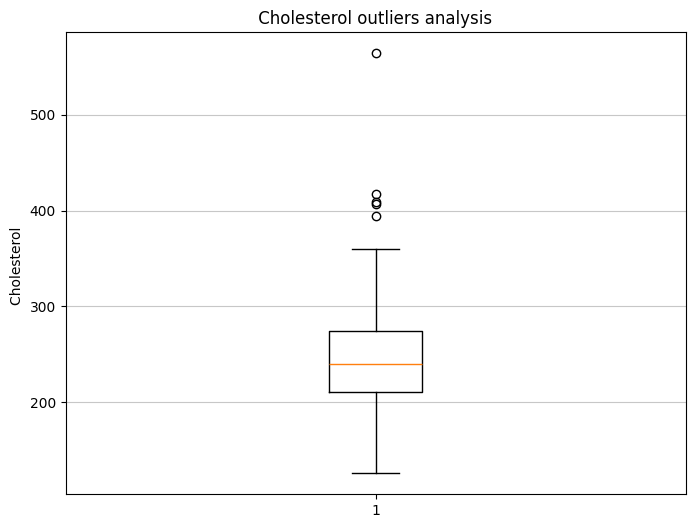

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.boxplot(df['chol'])
plt.title(' Cholesterol outliers analysis ')
plt.ylabel('Cholesterol ')
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.show()

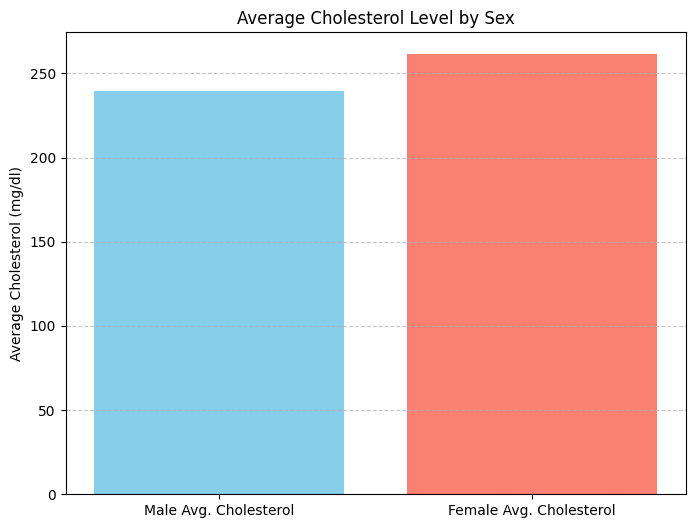

In [10]:
import matplotlib.pyplot as plt

males_chol_mean = df[df['sex'] == 1]['chol'].mean()
females_chol_mean = df[df['sex'] == 0]['chol'].mean()

chol_means = [males_chol_mean, females_chol_mean]
labels = ['Male Avg. Cholesterol', 'Female Avg. Cholesterol']
colors = ['skyblue', 'salmon']

plt.figure(figsize=(8, 6))
plt.bar(labels, chol_means, color=colors)
plt.title('Average Cholesterol Level by Sex')
plt.ylabel('Average Cholesterol (mg/dl)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_11033/3337816768.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Target 0 (No Heart Disease)', 'Target 1 (Heart Disease)'])


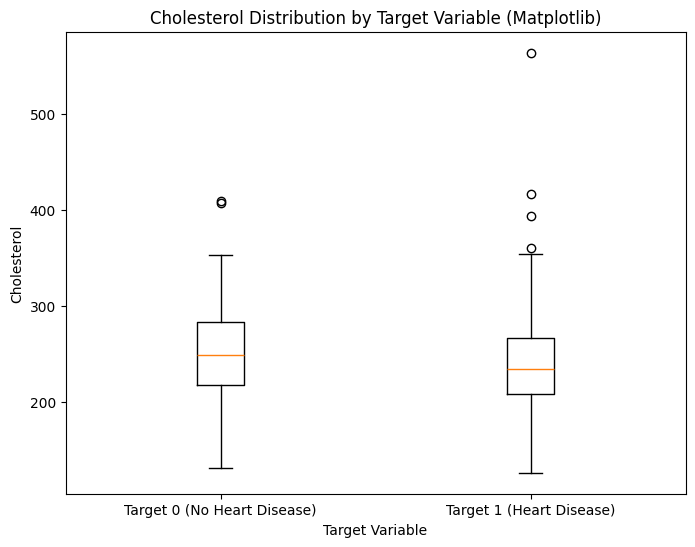

In [11]:
import matplotlib.pyplot as plt

# Separate 'chol' values based on the 'target' variable
chol_target_0 = df[df['target'] == 0]['chol']
chol_target_1 = df[df['target'] == 1]['chol']

# Create a list of the data to plot
data_to_plot = [chol_target_0, chol_target_1]

plt.figure(figsize=(8, 6))
plt.boxplot(data_to_plot, labels=['Target 0 (No Heart Disease)', 'Target 1 (Heart Disease)'])
plt.title('Cholesterol Distribution by Target Variable (Matplotlib)')
plt.xlabel('Target Variable')
plt.ylabel('Cholesterol')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

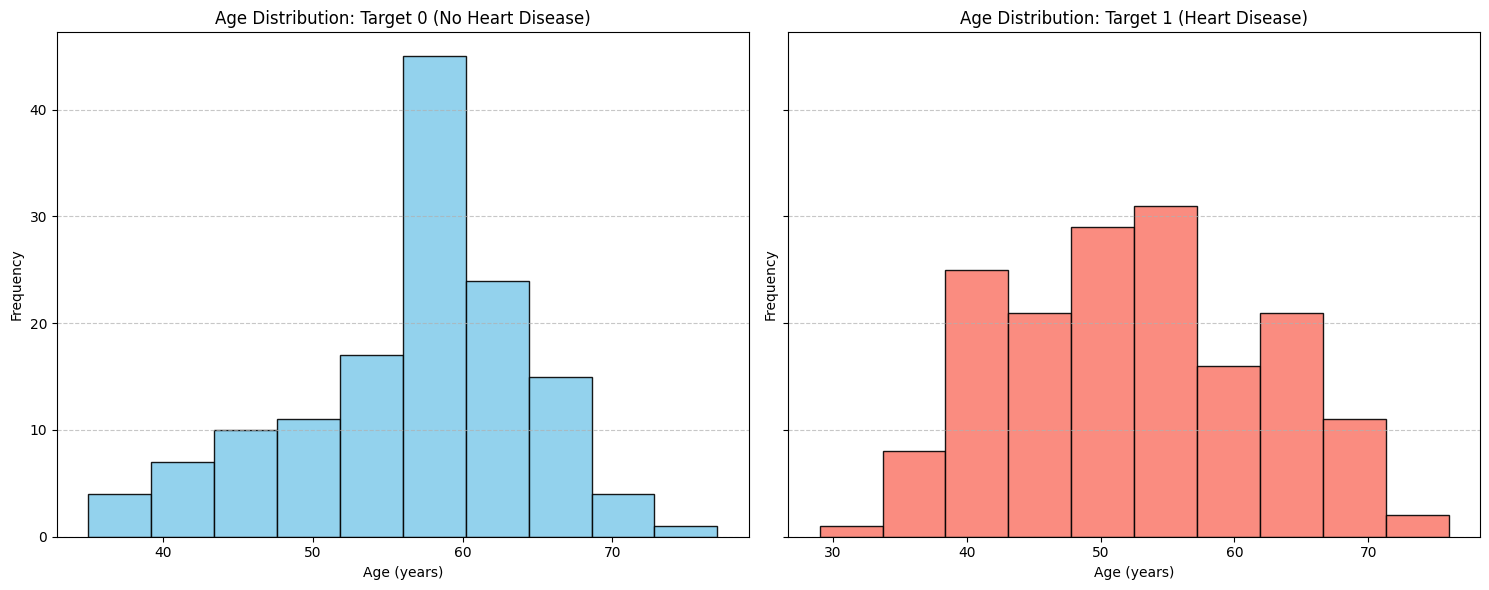

In [12]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True) # sharey=True ensures same y-axis scale

# Filter age data for target == 0 and target == 1
age_target_0 = df[df['target'] == 0]['age']
age_target_1 = df[df['target'] == 1]['age']

# Plot histogram for Target 0 (No Heart Disease) on the first subplot
axes[0].hist(age_target_0, bins=10, alpha=0.9, color='skyblue', edgecolor='black')
axes[0].set_title('Age Distribution: Target 0 (No Heart Disease)')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot histogram for Target 1 (Heart Disease) on the second subplot
axes[1].hist(age_target_1, bins=10, alpha=0.9, color='salmon', edgecolor='black')
axes[1].set_title('Age Distribution: Target 1 (Heart Disease)')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Frequency') # Label only for consistency, as y-axis is shared
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

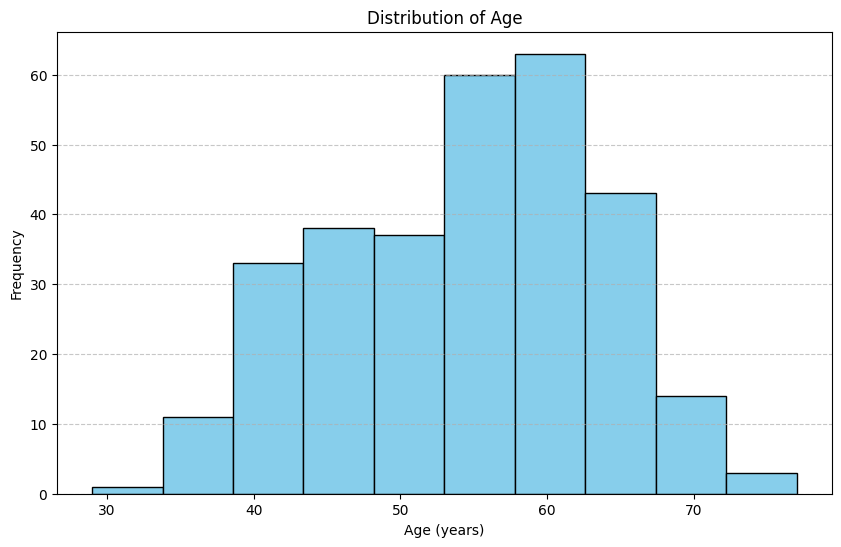

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

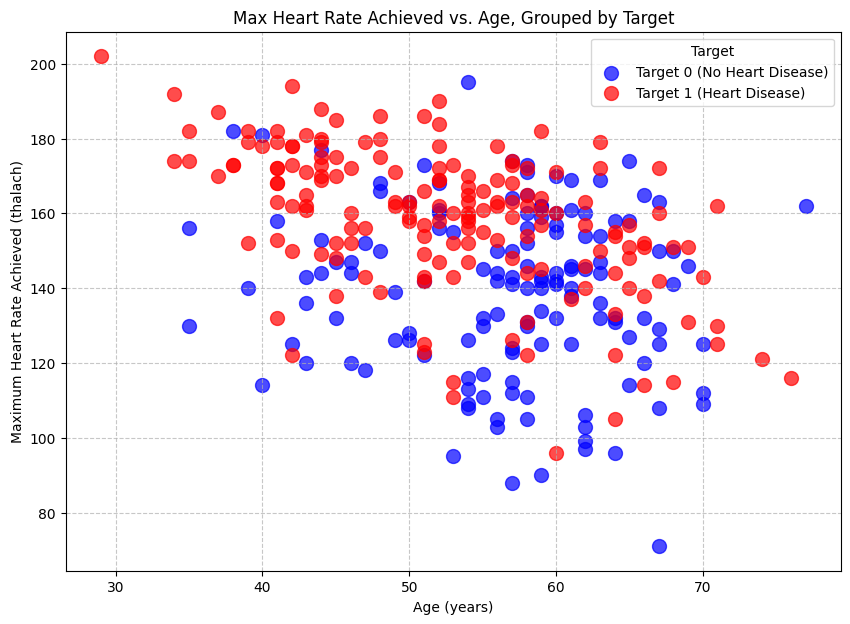

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Filter data for each target group
df_target_0 = df[df['target'] == 0]
df_target_1 = df[df['target'] == 1]

# Plot scatter for target 0
plt.scatter(df_target_0['age'], df_target_0['thalach'], color='blue', label='Target 0 (No Heart Disease)', alpha=0.7, s=100)

# Plot scatter for target 1
plt.scatter(df_target_1['age'], df_target_1['thalach'], color='red', label='Target 1 (Heart Disease)', alpha=0.7, s=100)

plt.title('Max Heart Rate Achieved vs. Age, Grouped by Target')
plt.xlabel('Age (years)')
plt.ylabel('Maximum Heart Rate Achieved (thalach)')
plt.legend(title='Target')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

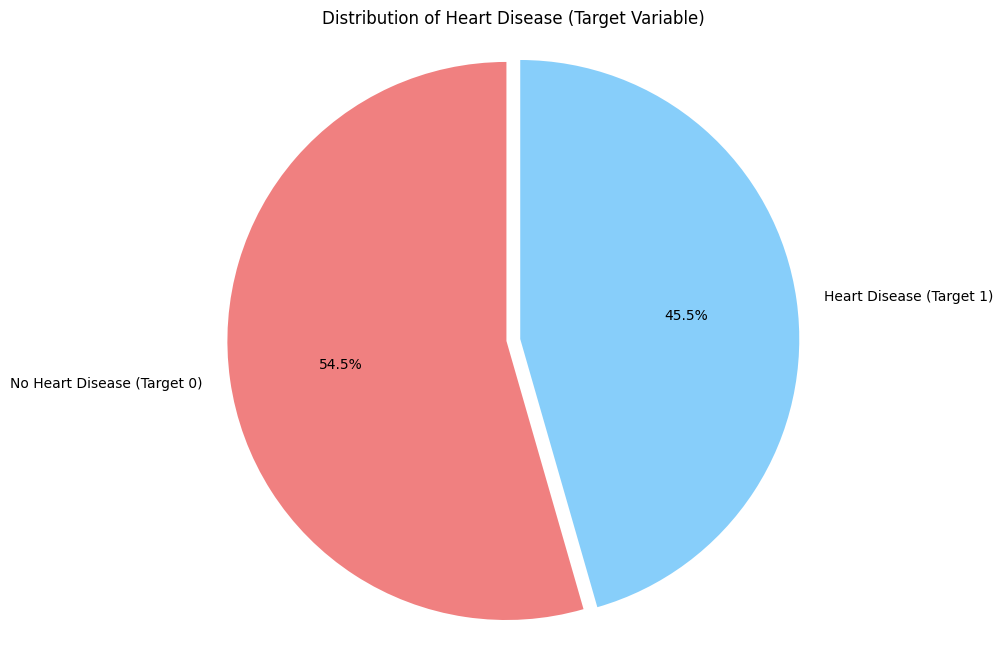

In [15]:
import matplotlib.pyplot as plt

# Count the occurrences of each unique value in the 'target' column
target_counts = df['target'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(target_counts, labels=['No Heart Disease (Target 0)', 'Heart Disease (Target 1)'], colors= ['lightcoral', 'lightskyblue'], autopct='%1.1f%%', startangle=90, explode=[0.05, 0])
plt.title('Distribution of Heart Disease (Target Variable)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

<Axes: xlabel='age', ylabel='thalach'>

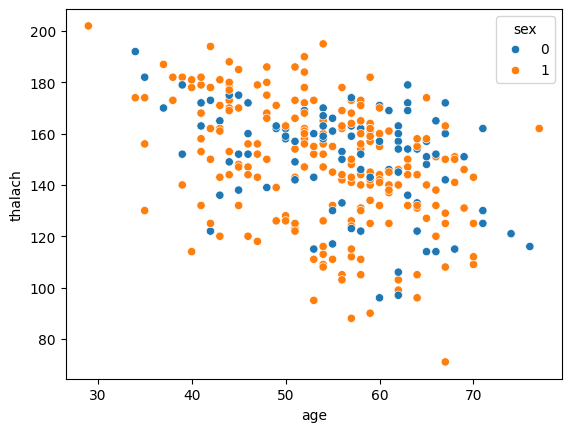

In [16]:
import seaborn as sns
# axes level
sns.scatterplot(data = df , x = 'age' , y= 'thalach'  , hue = 'sex')

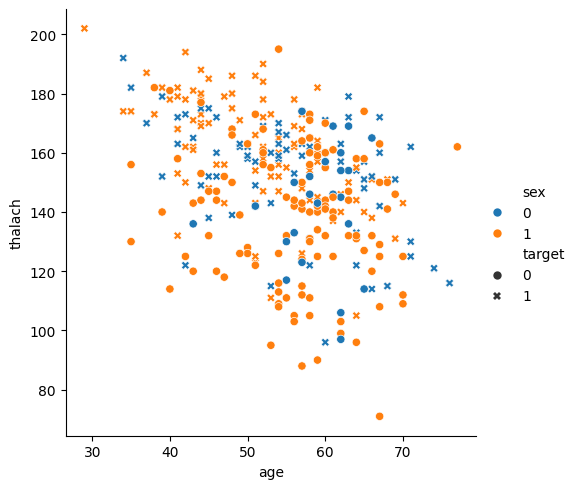

In [17]:
sns.relplot(data = df , x = 'age' , y= 'thalach'  , hue = 'sex' , kind = 'scatter' , style = 'target')
# figure level

In [18]:
import plotly.express as px

df2 = px.data.gapminder()

df2



,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


<Axes: xlabel='year', ylabel='lifeExp'>

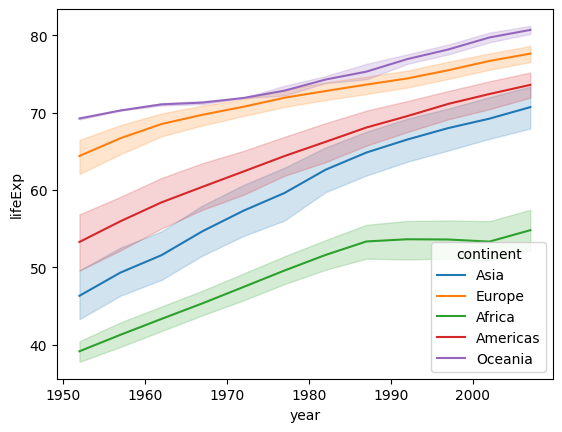

In [19]:
sns.lineplot(data = df2 , x ='year' , y = 'lifeExp' , hue = 'continent')


In [20]:
temp_df = df2[df2['country'].isin(['India' , 'Zimbabwe' , 'Pakistan'])]
temp_df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
696,India,Asia,1952,37.373,372000000,546.565749,IND,356
697,India,Asia,1957,40.249,409000000,590.061996,IND,356
698,India,Asia,1962,43.605,454000000,658.347151,IND,356
699,India,Asia,1967,47.193,506000000,700.770611,IND,356
700,India,Asia,1972,50.651,567000000,724.032527,IND,356
701,India,Asia,1977,54.208,634000000,813.337323,IND,356
702,India,Asia,1982,56.596,708000000,855.723538,IND,356
703,India,Asia,1987,58.553,788000000,976.512676,IND,356
704,India,Asia,1992,60.223,872000000,1164.406809,IND,356
705,India,Asia,1997,61.765,959000000,1458.817442,IND,356


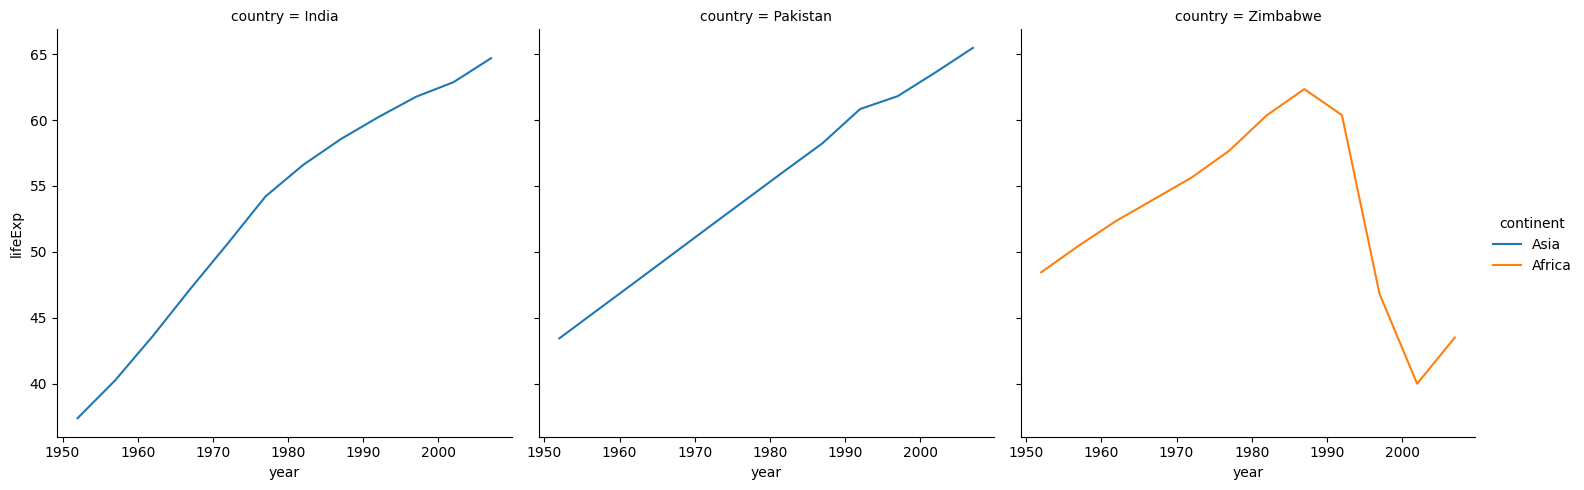

In [21]:
sns.relplot(data = temp_df , x = 'year' , y = 'lifeExp' , hue = 'continent' , col = 'country' , kind = 'line')
#

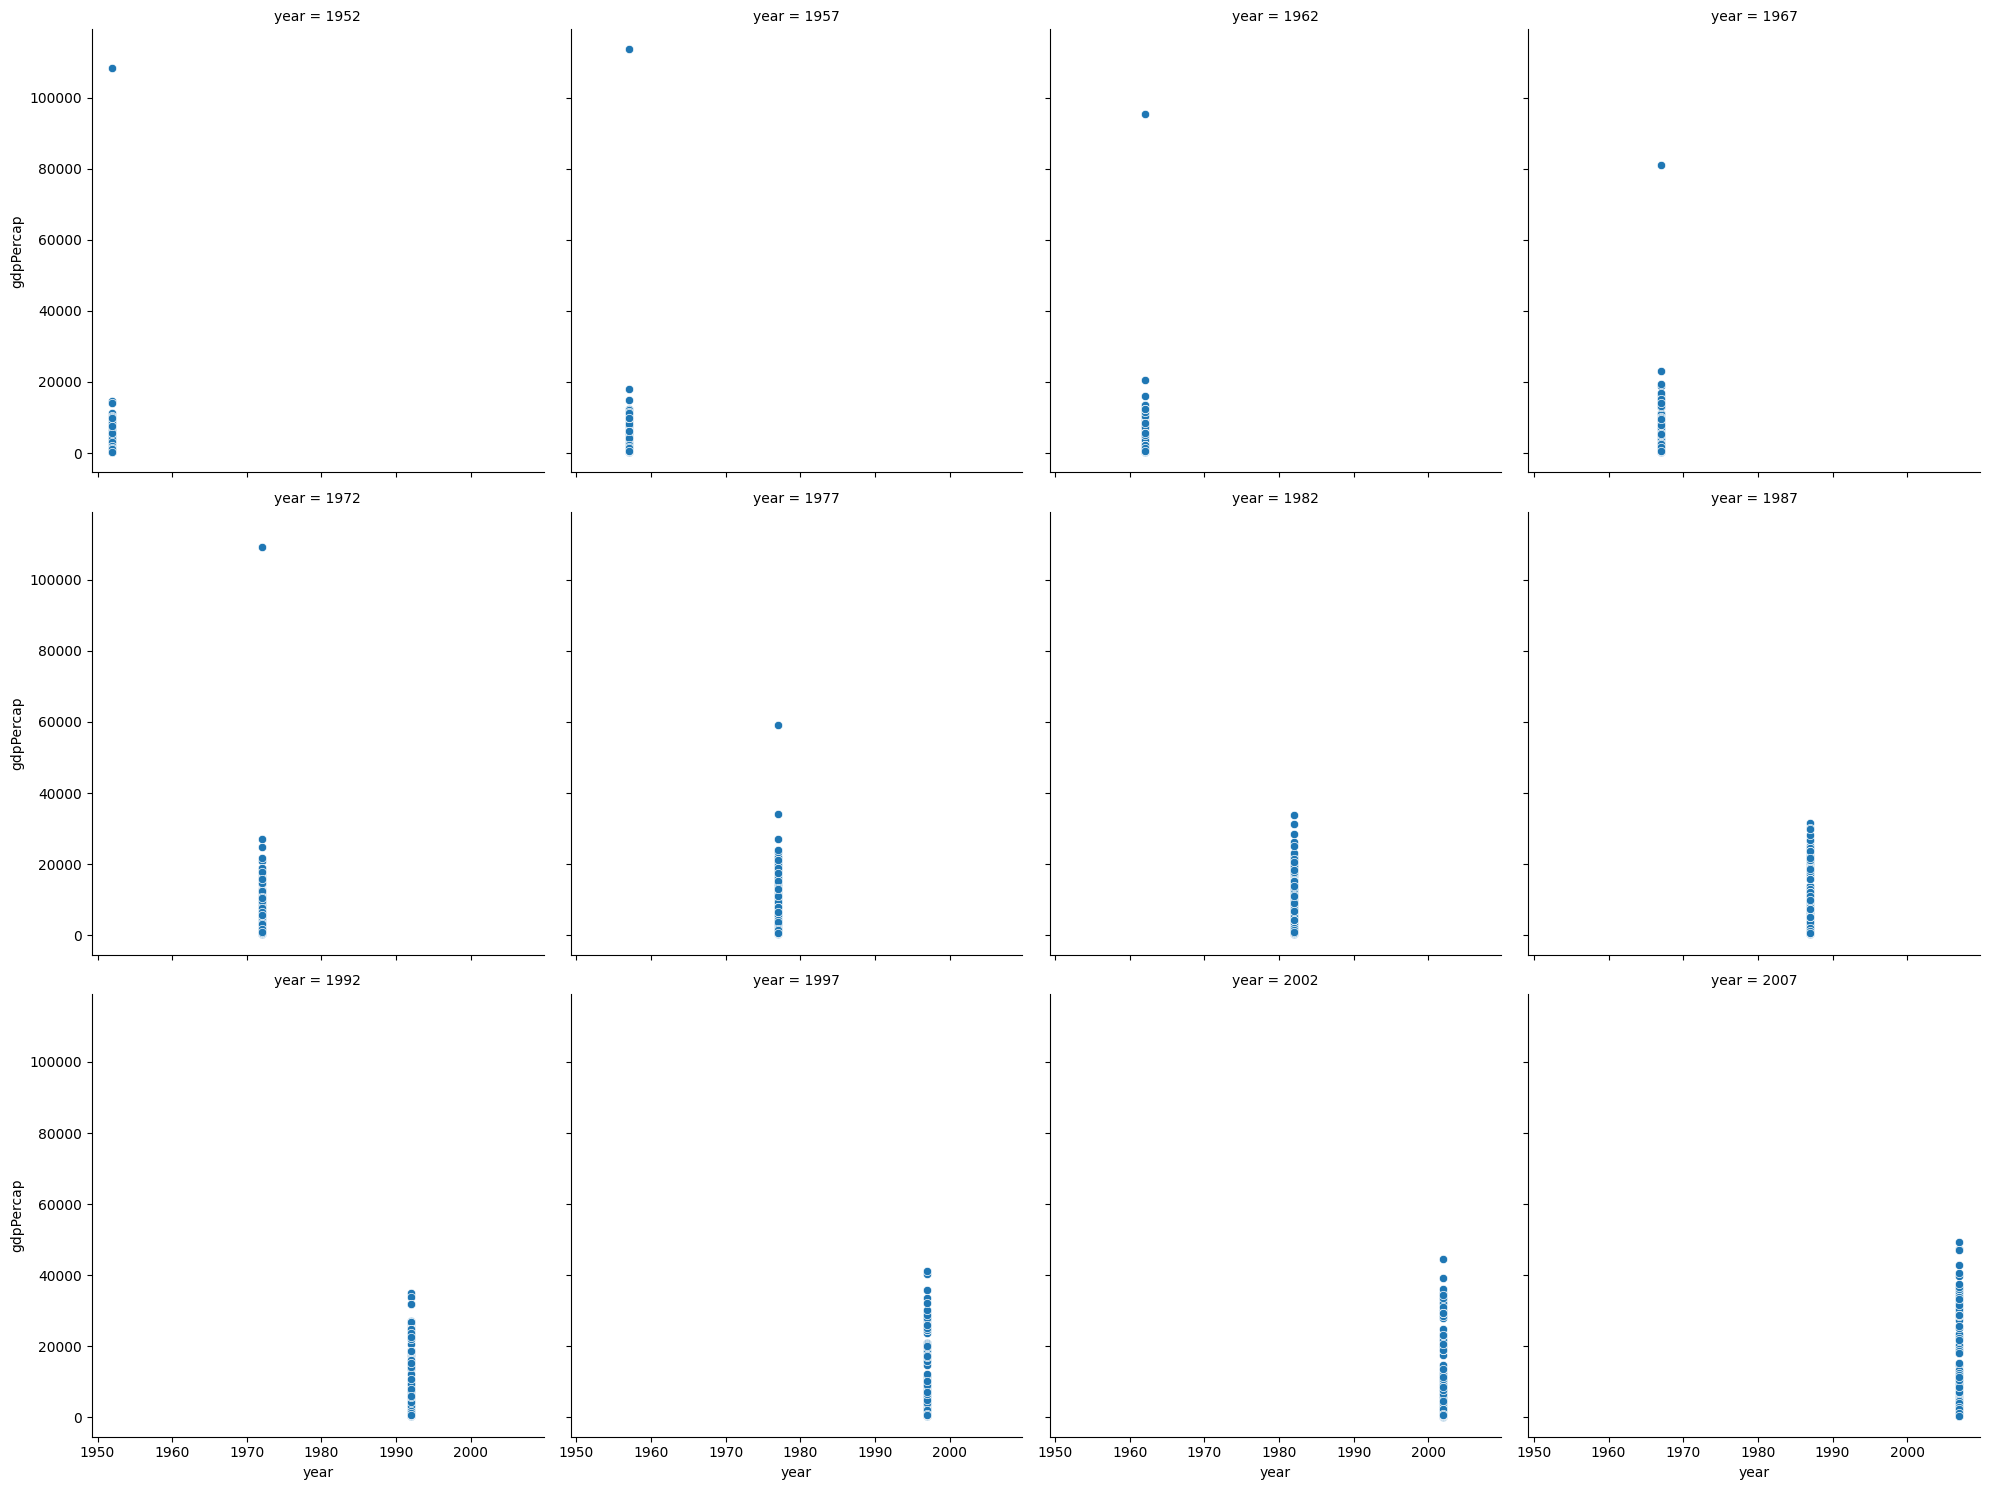

In [22]:
sns.relplot(data = df2 , x= 'year' , y = 'gdpPercap' ,  col = 'year' , kind = 'scatter' , col_wrap=4)
#

In [28]:
t = df2.pivot(index = 'country' , columns= 'year' , values = 'lifeExp')
plt.figure(figsize=(100, 100))

sns.heatmap(t , annot=True ,linewidth = 0.5)


<Axes: xlabel='year', ylabel='country'>

<Axes: xlabel='chol', ylabel='Count'>

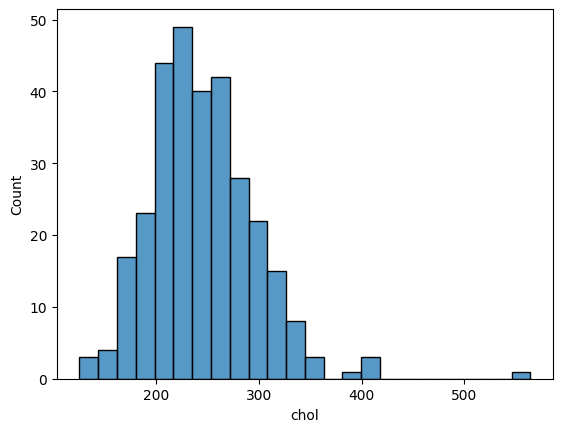

In [24]:
sns.histplot(data = df , x = 'chol' )

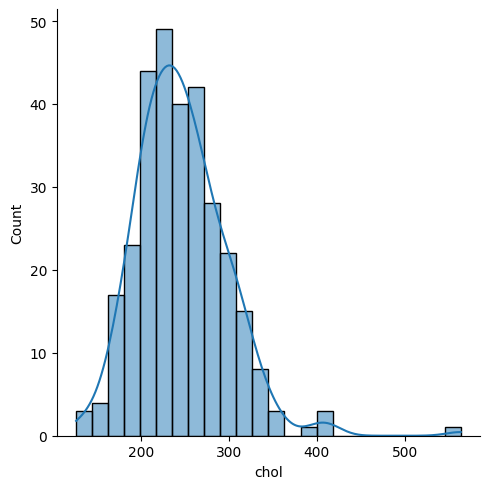

In [25]:
sns.displot(data = df , x = 'chol' , kde = True)
#

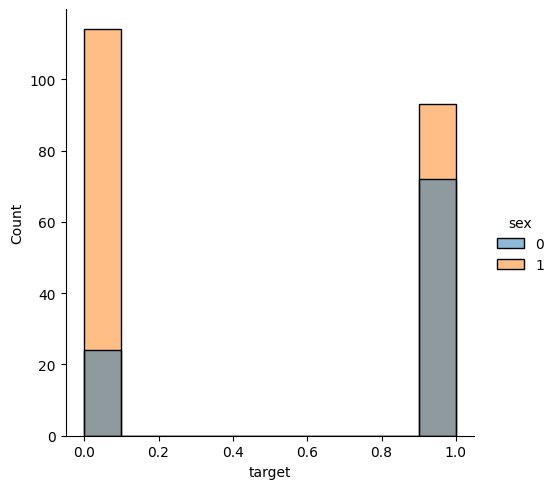

In [26]:
sns.displot(data = df , x = 'target' , hue = 'sex')

<Axes: xlabel='chol', ylabel='Density'>

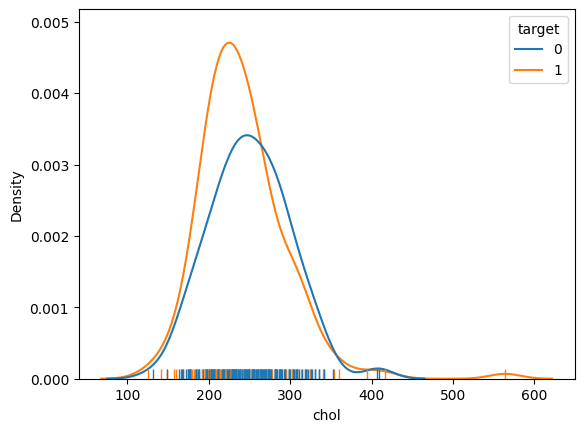

In [27]:
sns.kdeplot(data = df , x = 'chol' , hue = 'target')
sns.rugplot(data = df , x = 'chol' , hue = 'target')

<Axes: xlabel='target', ylabel='count'>

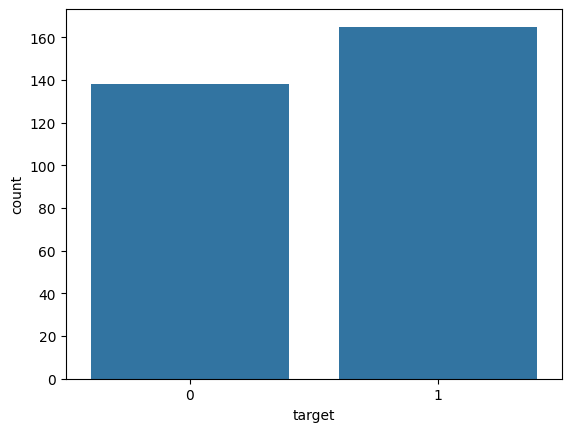

In [31]:
sns.countplot(data = df , x = 'target')

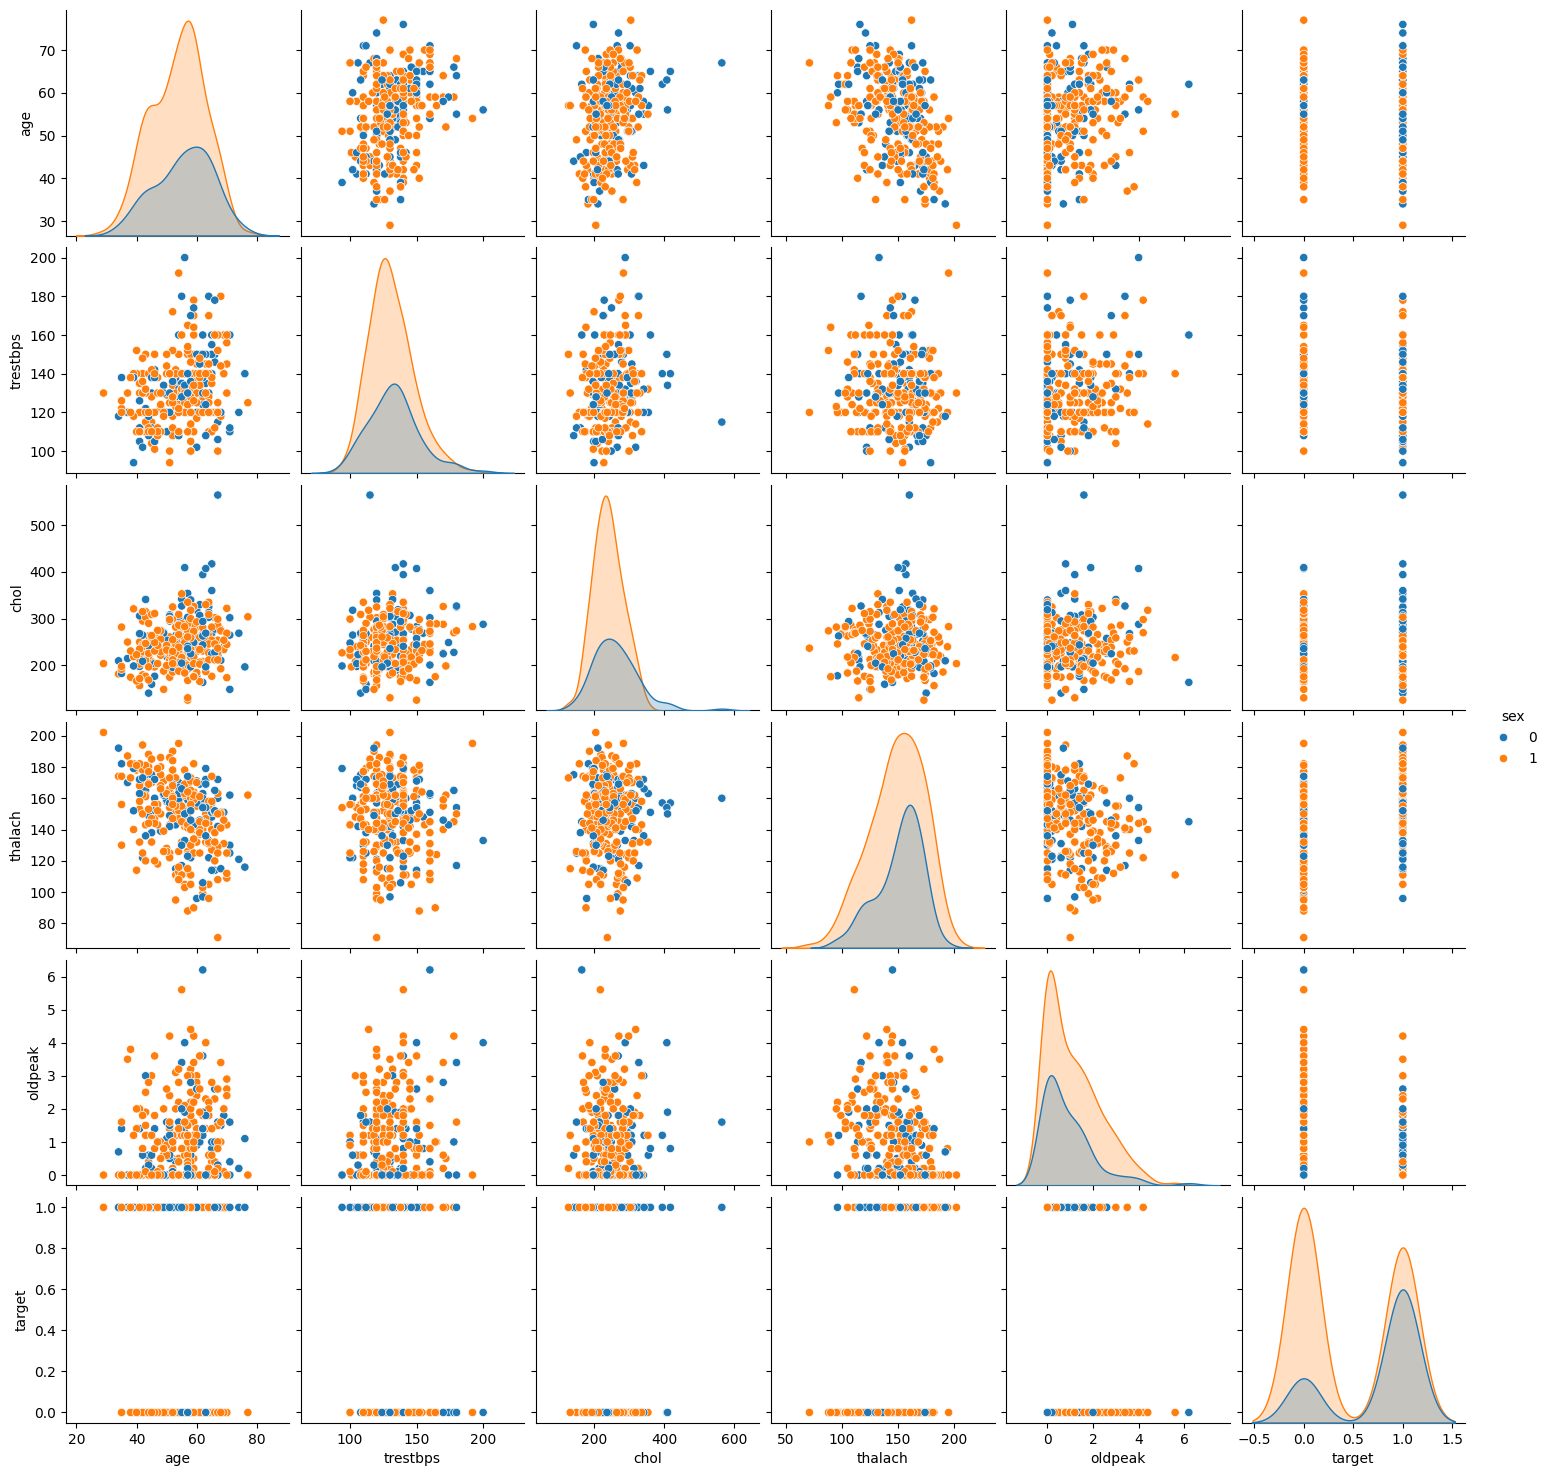

In [33]:
sns.pairplot(df, hue='sex' )